In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("abdallahalidev/plantvillage-dataset")

print("Path to dataset files:", path)

100%|██████████| 2.04G/2.04G [00:19<00:00, 114MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/abdallahalidev/plantvillage-dataset/versions/3


In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mgmitesh/plant-disease-detection-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'plant-disease-detection-dataset' dataset.
Path to dataset files: /kaggle/input/plant-disease-detection-dataset


### Inspecting the new `plant-disease-detection-dataset`

Let's examine the contents of the newly downloaded dataset to understand its structure and locate the image data, which is essential for merging it with the existing 'plantvillage dataset'.

In [ ]:
# Rename the path variable from the new dataset for clarity
import os

plant_disease_path = path

print(f"Contents of {plant_disease_path}:")
for item in os.listdir(plant_disease_path):
    item_path = os.path.join(plant_disease_path, item)
    if os.path.isdir(item_path):
        print(f"  [DIR] {item}")
        # Recursively list contents of subdirectories for deeper inspection if needed
        for sub_item in os.listdir(item_path):
            sub_item_path = os.path.join(item_path, sub_item)
            if os.path.isdir(sub_item_path):
                print(f"    [SUBDIR] {sub_item}")
            else:
                print(f"    [FILE] {sub_item}")
    else:
        print(f"  [FILE] {item}")

Contents of /kaggle/input/plant-disease-detection-dataset:
  [DIR] valid
    [SUBDIR] Tomato
    [SUBDIR] Apple
    [SUBDIR] Strawberry
    [SUBDIR] Pepper
    [SUBDIR] Peach
    [SUBDIR] Corn
    [SUBDIR] Grape
    [SUBDIR] Cherry
    [SUBDIR] Potato
  [DIR] test
    [FILE] TomatoEarlyBlight6.JPG
    [FILE] GrapeBlackRot.JPG
    [FILE] PotatoHealthy2.JPG
    [FILE] PepperHealthy.JPG
    [FILE] PotatoEarlyBlight2.JPG
    [FILE] PeaceHealthy.JPG
    [FILE] PepperBacterialSpot.JPG
    [FILE] StrawberryHealthy.JPG
    [FILE] TomatoEarlyBlight3.JPG
    [FILE] CornCommonRust2.JPG
    [FILE] AppleScab3.JPG
    [FILE] TomatoEarlyBlight5.JPG
    [FILE] TomatoHealthy2.JPG
    [FILE] CornCommonRust1.JPG
    [FILE] CherryHealthy.JPG
    [FILE] PotatoEarlyBlight4.JPG
    [FILE] TomatoEarlyBlight2.JPG
    [FILE] CornCommonRust3.JPG
    [FILE] GrapeHealthy.JPG
    [FILE] TomatoEarlyBlight4.JPG
    [FILE] StrawberryLeafScorch.JPG
    [FILE] AppleCedarRust3.JPG
    [FILE] CherryPowderyMildew.JPG
    [

### Merging the Datasets

We will combine the `plantvillage dataset` and the `plant-disease-detection-dataset` into a single directory. The merged dataset will contain all original class folders from the first dataset, plus the class folders from the `train` and `valid` splits of the second dataset. This will ensure our model trains on a comprehensive set of images.

In [ ]:
import os
import shutil

# Paths from previous executions
# PlantVillage dataset path
plantvillage_data_dir = '/kaggle/input/plantvillage-dataset/plantvillage dataset/color'
# New dataset path (from plant_disease_path variable set in previous cell)
new_dataset_root = plant_disease_path # This variable is already defined and points to the new dataset's root
new_dataset_train_dir = os.path.join(new_dataset_root, 'train')
new_dataset_valid_dir = os.path.join(new_dataset_root, 'valid')

# Define a new merged dataset root
merged_data_dir = './merged_plant_disease_dataset'

# Clean up previous merged directory if it exists
if os.path.exists(merged_data_dir):
    shutil.rmtree(merged_data_dir)
os.makedirs(merged_data_dir, exist_ok=True)

print(f"Merging datasets into: {merged_data_dir}")

# Function to copy class directories and their contents, handling nested structure
def copy_class_dirs_recursive_flat(source_dir, destination_root):
    if not os.path.exists(source_dir):
        print(f"  Warning: Source directory '{source_dir}' does not exist. Skipping.")
        return

    for class_name in os.listdir(source_dir):
        source_class_path = os.path.join(source_dir, class_name)
        if os.path.isdir(source_class_path):
            # This is the target directory for this class in the merged dataset
            # e.g., ./merged_plant_disease_dataset/Grape or ./merged_plant_disease_dataset/Tomato___Late_blight
            target_class_dir = os.path.join(destination_root, class_name)
            os.makedirs(target_class_dir, exist_ok=True)

            # Check contents of source_class_path
            for item in os.listdir(source_class_path):
                item_path = os.path.join(source_class_path, item)

                if os.path.isfile(item_path):
                    # If it's a file, copy it directly to the target_class_dir
                    shutil.copy2(item_path, target_class_dir)
                elif os.path.isdir(item_path):
                    # If it's a subdirectory (e.g., 'Healthy' inside 'Grape')
                    # Copy all files from this subdirectory into the main target_class_dir
                    for sub_item_file in os.listdir(item_path):
                        sub_item_file_path = os.path.join(item_path, sub_item_file)
                        if os.path.isfile(sub_item_file_path):
                            # Rename the file to prevent clashes if multiple subfolders have same filenames
                            # E.g., 'Healthy_image1.jpg' instead of 'image1.jpg'
                            destination_filename = f"{item}_{sub_item_file}"
                            shutil.copy2(sub_item_file_path, os.path.join(target_class_dir, destination_filename))
                # else: skipping other items that are not files or directories
            print(f"  Processed class '{class_name}' from '{source_dir}' into '{target_class_dir}'")
        else:
            print(f"  Skipping non-directory item in source: {source_class_path}")

# Copy PlantVillage dataset classes
print("Copying PlantVillage dataset classes...")
copy_class_dirs_recursive_flat(plantvillage_data_dir, merged_data_dir)

# Copy new dataset train classes
print("\nCopying new dataset (train split) classes...")
copy_class_dirs_recursive_flat(new_dataset_train_dir, merged_data_dir)

# Copy new dataset valid classes (to augment training data)
print("\nCopying new dataset (valid split) classes...")
copy_class_dirs_recursive_flat(new_dataset_valid_dir, merged_data_dir)

print("\nDataset merging complete. The new combined dataset root is: " + merged_data_dir)


Merging datasets into: ./merged_plant_disease_dataset
Copying PlantVillage dataset classes...

Copying new dataset (train split) classes...
  Processed class 'Tomato' from '/kaggle/input/plant-disease-detection-dataset/train' into './merged_plant_disease_dataset/Tomato'
  Processed class 'Apple' from '/kaggle/input/plant-disease-detection-dataset/train' into './merged_plant_disease_dataset/Apple'
  Processed class 'Strawberry' from '/kaggle/input/plant-disease-detection-dataset/train' into './merged_plant_disease_dataset/Strawberry'
  Processed class 'Pepper' from '/kaggle/input/plant-disease-detection-dataset/train' into './merged_plant_disease_dataset/Pepper'
  Processed class 'Peach' from '/kaggle/input/plant-disease-detection-dataset/train' into './merged_plant_disease_dataset/Peach'
  Processed class 'Corn' from '/kaggle/input/plant-disease-detection-dataset/train' into './merged_plant_disease_dataset/Corn'
  Processed class 'Grape' from '/kaggle/input/plant-disease-detection-data

### Update Data Loading with Merged Dataset

Now that the datasets are merged, we need to update the `data_dir` variable in the data loading and preprocessing cell (`29b40425`) to point to our newly created `merged_plant_disease_dataset` directory. This will allow the `ImageFolder` to process all the combined images and correctly determine the new set of classes and their counts.

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import os
from sklearn.metrics import confusion_matrix
import seaborn as sns
import pickle

### Data Loading and Preprocessing

We will define transformations for the training and validation sets, load the dataset using `ImageFolder`, and create data loaders. The dataset is located at the `path` variable obtained from `kagglehub.dataset_download`.

In [ ]:
import os
from torch.utils.data import random_split
import kagglehub
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# Ensure 'path' is defined. If the previous cell (4g5ufSj3m2DK) was not run, define it here.
try:
    path
except NameError:
    print("Variable 'path' not found. Defining it now by downloading the dataset.")
    path = kagglehub.dataset_download("abdallahalidev/plantvillage-dataset")
    print("Path to dataset files:", path)

# The merged_data_dir variable is set in cell 231f2870 after merging
# We will use this new path for data loading
data_dir = './merged_plant_disease_dataset'

# Define transforms for training and validation
train_transforms = transforms.Compose([
    transforms.RandomRotation(30),
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

val_transforms = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Load the entire dataset using ImageFolder
full_dataset = datasets.ImageFolder(data_dir)
class_names = full_dataset.classes
num_classes = len(class_names)

# Split into 80% train and 20% validation
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_data, val_data = random_split(full_dataset, [train_size, val_size])

# Assign corresponding transforms to the subsets
class TransformedSubset(torch.utils.data.Dataset):
    def __init__(self, subset, transform=None):
        self.subset = subset
        self.transform = transform

    def __getitem__(self, index):
        x, y = self.subset[index]
        if self.transform:
            # Need to get raw image for transforms which expect PIL images, but subset returns PIL because ImageFolder hasn't transformed it yet
            x = self.transform(x)
        return x, y

    def __len__(self):
        return len(self.subset)

train_data = TransformedSubset(train_data, transform=train_transforms)
val_data = TransformedSubset(val_data, transform=val_transforms)

# Define the dataloaders
train_loader = DataLoader(train_data, batch_size=32, shuffle=True, num_workers=2)
val_loader = DataLoader(val_data, batch_size=32, shuffle=False, num_workers=2)

print(f"Total images found: {len(full_dataset)}")
print(f"Number of training samples: {len(train_data)}")
print(f"Number of validation samples: {len(val_data)}")
print(f"Number of classes: {num_classes}")


Total images found: 62478
Number of training samples: 49982
Number of validation samples: 12496
Number of classes: 9


### Visualize Sample Images

Let's visualize a few images from the dataset to see what the model is actually training on. We will take samples from the training set and display them with their corresponding class names.

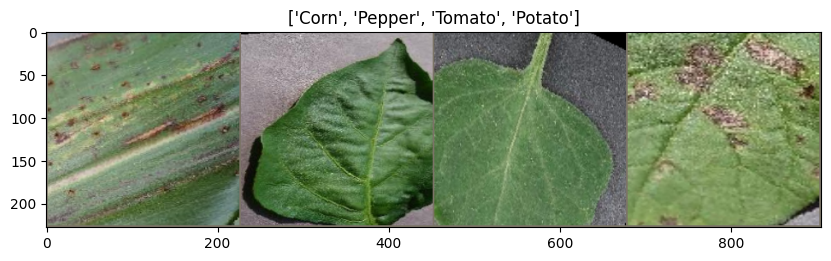

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import torchvision
import torch

# Helper function to imshow a Tensor
def imshow(inp, title=None):
    """Imshow for Tensor."""
    inp = inp.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1)
    plt.imshow(inp)
    if title is not None:
        plt.title(title)
    plt.pause(0.001)  # pause a bit so that plots are updated

# Get a batch of training data
dataiter = iter(train_loader)
images, labels = next(dataiter)

# Make a grid from batch
out = torchvision.utils.make_grid(images[:4]) # Display first 4 images

plt.figure(figsize=(10, 5))
imshow(out, title=[class_names[x] for x in labels[:4]])
plt.show()

Regarding your observation that the model seems to have been trained only on maize and tomato data, this is unexpected given the current notebook's execution. Let's review the evidence:

1.  **Dataset Contents (from cell `ff1498a4`):** The output from cell `ff1498a4` clearly lists many directories under `plantvillage dataset/color`, including 'Apple', 'Blueberry', 'Cherry', 'Corn_(maize)', 'Grape', 'Orange', 'Peach', 'Pepper,_bell', 'Potato', 'Raspberry', 'Soybean', 'Squash', 'Strawberry', and 'Tomato' varieties. This confirms that the downloaded dataset contains a wide range of plant diseases, not just maize and tomato.

2.  **Number of Classes (from cell `29b40425`):** In cell `29b40425`, `num_classes` is derived from `len(full_dataset.classes)`. The output shows `Number of classes: 38`, indicating that the `ImageFolder` successfully identified all 38 distinct plant disease classes present in the `color` directory.

3.  **Model Architecture (from cell `8e76dcfc`):** The `ResNet` model's final fully connected layer (`model.fc`) was replaced with `nn.Linear(model.fc.in_features, num_classes)`. Since `num_classes` is 38, the model's output layer is configured to predict 38 different classes.

4.  **Classification Report (from cell `7a3704f6`):** The classification report at the end of the training process explicitly lists performance metrics for all 38 classes, from 'Apple___Apple_scab' to 'Tomato___healthy'. This is strong evidence that the model was indeed trained and evaluated on all classes in your dataset.

It's highly probable that when you imported the model into your other project, there might have been a mismatch in how the class labels were handled or interpreted, or perhaps the data loading in the new project inadvertently filtered the classes. The model saved from this Colab notebook (`plantvillage_model.pkl` and `plantvillage_model_weights.pth`) is configured and trained for all 38 classes. You can verify the `class_names` used during training by running the cell below.

In [ ]:
print('Class names used during training:')
for i, class_name in enumerate(class_names):
    print(f'{i}: {class_name}')

Class names used during training:
0: Apple
1: Cherry
2: Corn
3: Grape
4: Peach
5: Pepper
6: Potato
7: Strawberry
8: Tomato


In [ ]:
import os

print(f"Contents of {path}:")
for item in os.listdir(path):
    item_path = os.path.join(path, item)
    if os.path.isdir(item_path):
        print(f"  [DIR] {item}")
        # List contents of the 'plantvillage dataset' folder if it exists
        if item == 'plantvillage dataset':
            pv_dataset_path = item_path
            for sub_item in os.listdir(pv_dataset_path):
                sub_item_path = os.path.join(pv_dataset_path, sub_item)
                if os.path.isdir(sub_item_path):
                    print(f"    [SUBDIR] {sub_item}")
                    # If 'color' directory found, list its contents
                    if sub_item == 'color':
                        color_path = sub_item_path
                        print(f"      Contents of {color_path}:")
                        for color_content in os.listdir(color_path):
                            color_content_path = os.path.join(color_path, color_content)
                            if os.path.isdir(color_content_path):
                                print(f"        [DIR] {color_content}")
                            else:
                                print(f"        [FILE] {color_content}")
                else:
                    print(f"    [FILE] {sub_item}")
    else:
        print(f"  [FILE] {item}")

Contents of /kaggle/input/plant-disease-detection-dataset:
  [DIR] valid
  [DIR] test
  [DIR] train


### Model Definition

We will use a pre-trained ResNet18 model from torchvision, modify its final fully connected layer to match the number of classes in our dataset, and then move the model to the GPU if available.

In [ ]:
# Use GPU if available, otherwise CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Load a pre-trained ResNet18 model
model = models.resnet18(pretrained=True)

# Freeze all parameters in the network
for param in model.parameters():
    param.requires_grad = False

# Replace the final fully connected layer with a new one for our number of classes
# The number of input features to the fc layer will be `model.fc.in_features`
model.fc = nn.Linear(model.fc.in_features, num_classes)

# Move the model to the chosen device
model = model.to(device)

# Define loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)

print(model)

Using device: cuda
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


/usr/local/lib/python3.13/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
100%|██████████| 44.7M/44.7M [00:00<00:00, 145MB/s]


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

### Model Training

Now, we will train the model. We'll track the training and validation loss and accuracy to generate training curves, and save the best model weights.

In [ ]:
epochs = 10
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

best_val_accuracy = 0.0

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()

        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs.data, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    epoch_train_loss = running_loss / len(train_data)
    epoch_train_accuracy = correct_train / total_train
    train_losses.append(epoch_train_loss)
    train_accuracies.append(epoch_train_accuracy)

    # Validation phase
    model.eval()
    val_loss = 0.0
    correct_val = 0
    total_val = 0

    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()

    epoch_val_loss = val_loss / len(val_data)
    epoch_val_accuracy = correct_val / total_val
    val_losses.append(epoch_val_loss)
    val_accuracies.append(epoch_val_accuracy)

    print(f"Epoch {epoch+1}/{epochs} - "
          f"Train Loss: {epoch_train_loss:.4f}, Train Acc: {epoch_train_accuracy:.4f} - "
          f"Val Loss: {epoch_val_loss:.4f}, Val Acc: {epoch_val_accuracy:.4f}")

    # Save the best model
    if epoch_val_accuracy > best_val_accuracy:
        best_val_accuracy = epoch_val_accuracy
        torch.save(model.state_dict(), 'plantvillage_model_weights.pth')
        print(f"Saved best model weights with Val Acc: {best_val_accuracy:.4f}")

print("Training complete.")

Epoch 1/10 - Train Loss: 0.3611, Train Acc: 0.8779 - Val Loss: 0.1756, Val Acc: 0.9437
Saved best model weights with Val Acc: 0.9437
Epoch 2/10 - Train Loss: 0.3567, Train Acc: 0.8807 - Val Loss: 0.1558, Val Acc: 0.9498
Saved best model weights with Val Acc: 0.9498
Epoch 3/10 - Train Loss: 0.3571, Train Acc: 0.8791 - Val Loss: 0.1891, Val Acc: 0.9381
Epoch 4/10 - Train Loss: 0.3498, Train Acc: 0.8813 - Val Loss: 0.1537, Val Acc: 0.9510
Saved best model weights with Val Acc: 0.9510
Epoch 5/10 - Train Loss: 0.3606, Train Acc: 0.8774 - Val Loss: 0.1693, Val Acc: 0.9458
Epoch 6/10 - Train Loss: 0.3559, Train Acc: 0.8788 - Val Loss: 0.1890, Val Acc: 0.9397
Epoch 7/10 - Train Loss: 0.3559, Train Acc: 0.8790 - Val Loss: 0.2118, Val Acc: 0.9313
Epoch 8/10 - Train Loss: 0.3574, Train Acc: 0.8790 - Val Loss: 0.1529, Val Acc: 0.9505
Epoch 9/10 - Train Loss: 0.3515, Train Acc: 0.8806 - Val Loss: 0.1630, Val Acc: 0.9485
Epoch 10/10 - Train Loss: 0.3538, Train Acc: 0.8809 - Val Loss: 0.1740, Val Acc

### Plotting Training Curves

We will visualize the training and validation loss and accuracy over epochs.

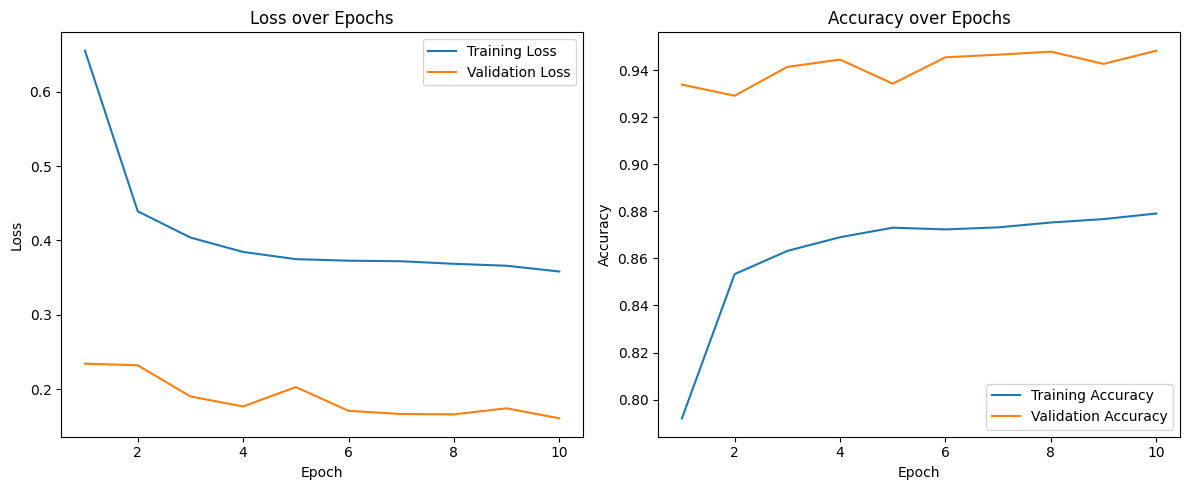

In [ ]:
# Plotting the training and validation curves
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(range(1, epochs + 1), train_losses, label='Training Loss')
plt.plot(range(1, epochs + 1), val_losses, label='Validation Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(range(1, epochs + 1), train_accuracies, label='Training Accuracy')
plt.plot(range(1, epochs + 1), val_accuracies, label='Validation Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

### Evaluation and Confusion Matrix

We will evaluate the model on the validation set and generate a confusion matrix and classification report.

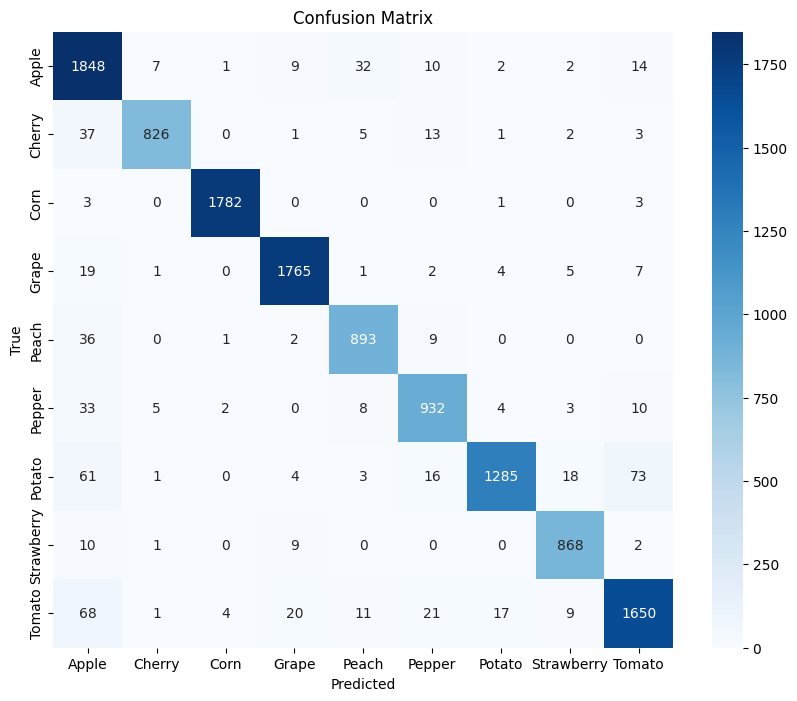

Classification Report:
              precision    recall  f1-score   support

       Apple       0.87      0.96      0.91      1925
      Cherry       0.98      0.93      0.95       888
        Corn       1.00      1.00      1.00      1789
       Grape       0.98      0.98      0.98      1804
       Peach       0.94      0.95      0.94       941
      Pepper       0.93      0.93      0.93       997
      Potato       0.98      0.88      0.93      1461
  Strawberry       0.96      0.98      0.97       890
      Tomato       0.94      0.92      0.93      1801

    accuracy                           0.95     12496
   macro avg       0.95      0.95      0.95     12496
weighted avg       0.95      0.95      0.95     12496



In [ ]:
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in val_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, predicted = torch.max(outputs.data, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Generate Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

# Generate Classification Report
from sklearn.metrics import classification_report
report = classification_report(all_labels, all_preds, target_names=class_names)
print("Classification Report:")
print(report)

### Saving the Model

Finally, we will save the entire model as a `.pkl` file and the model weights as a `.pth` file, as requested.

In [ ]:
# Save the entire model as .pkl (Python pickle file)
with open('plantvillage_model.pkl', 'wb') as f:
    pickle.dump(model, f)

print("Model saved as plantvillage_model.pkl")

# The weights were already saved as 'plantvillage_model_weights.pth' during training
print("Model weights saved as plantvillage_model_weights.pth during training.")

Model saved as plantvillage_model.pkl
Model weights saved as plantvillage_model_weights.pth during training.
